# **Tutorial:** Real-time Object Detection with YOLO

In this tutorial, you will learn how to use the YOLOv26 model with OpenCV to automatically detect and draw bounding boxes around objects in an image.

### **Step 1: Install Required Packages**

Install the necessary packages including OpenCV and other dependencies:

In [ ]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

Verify the installations:

In [ ]:
%pip show opencv-python ultralytics

### **Step 2: Import Required Libraries**

Import the libraries you will use:

In [2]:
import numpy as np
import math
import cv2
from ultralytics import YOLO
from matplotlib import pyplot as plt

### **Step 3: Load the YOLOv26 Model**

Load the pre-trained YOLOv26 model (automatically downloads if not available):

In [3]:
# Load a pretrained YOLO model version 26, nano (n) size
model = YOLO('yolo26n.pt')  # Using nano version for speed, other options: yolov26s.pt (small), yolov26m.pt (medium), yolov26l.pt (large), yolov26x.pt (extra large)

In [3]:
# Show class names the model can detect 
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

### **Step 4.1: Run YOLO on an Image**

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Define path to the image file
# source = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/cat.jpg"
source = "./animales.jpg"

# Run inference on the source
results = model(source, show=True)  # list of Results objects

### **Step 4.2: Run YOLO on an Image + save result in working directory + plot with matplotlib**

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/ivan/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/animales.jpg: 640x640 1 bird, 1 dog, 108.2ms
Speed: 4.7ms preprocess, 108.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/runs/detect/yolo_results


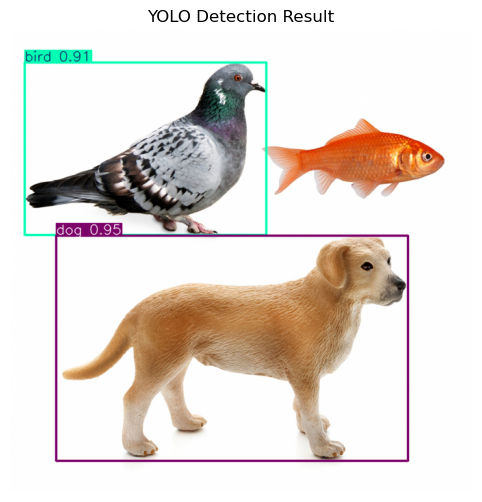

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16., 14.])
conf: tensor([0.9498, 0.9054])
data: tensor([[ 67.5730, 300.1736, 581.9563, 629.0758,   0.9498,  16.0000],
        [ 21.6873,  47.8934, 374.3872, 299.9319,   0.9054,  14.0000]])
id: None
is_track: False
orig_shape: (675, 675)
shape: torch.Size([2, 6])
xywh: tensor([[324.7646, 464.6247, 514.3833, 328.9022],
        [198.0373, 173.9127, 352.6999, 252.0385]])
xywhn: tensor([[0.4811, 0.6883, 0.7620, 0.4873],
        [0.2934, 0.2576, 0.5225, 0.3734]])
xyxy: tensor([[ 67.5730, 300.1736, 581.9563, 629.0758],
        [ 21.6873,  47.8934, 374.3872, 299.9319]])
xyxyn: tensor([[0.1001, 0.4447, 0.8622, 0.9320],
        [0.0321, 0.0710, 0.5546, 0.4443]])


In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Cargar modelo
model = YOLO("yolo26n.pt")

# Ruta de la imagen
source = "./animales.jpg"

# Inferencia + guardar resultado
results = model(
    source, 
    save=True,
    project="./",  # carpeta base
    name="yolo_results",                # subcarpeta
    exist_ok=True  # sobreescribe si ya existe
    )

# Mostrar con matplotlib
for r in results:
    img = r.plot()  # imagen con bounding boxes
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLO Detection Result")
    plt.show()

# (Opcional) imprimir info de detecciones
for r in results:
    print(r.boxes)

### **Step 5.1: Run YOLO on a saved video**

#### Option 1: Save the processed video on the working directory

In [ ]:
from ultralytics import YOLO
import cv2
import os

model = YOLO("yolo26n.pt")

source = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/classroom.mp4"
output_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/yolo_results/classroom-results.avi"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

results = model(source, stream=True)

out = None

for r in results:
    frame = r.plot()

    if out is None:
        h, w = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"MJPG")  # 🔥 estable en Mac
        out = cv2.VideoWriter(output_path, fourcc, 20, (w, h))

        print("Writer abierto:", out.isOpened())

    out.write(frame)

if out:
    out.release()
    print("Video guardado")
else
    print("Nada se guardó")

#### Option 2: Show the video on real-time

In [ ]:
from ultralytics import YOLO
import cv2

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Configure your video path
#video_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/Object Detection/fruit-and-vegetable-detection.mp4"
#video_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/Object Detection/car-detection.mp4"
video_path = "/Users/eugenio/Documents/Computer_Vision/UC.04 Object Detection/worker-zone-detection.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Verify video opened correctly
if not cap.isOpened():
    print("Error: Could not open video. Check the path.")
else:
    print("Video loaded successfully. Press 'q' to exit.")
    
    # Process each video frame
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break  # Finish when video ends
            
        # Run detection with YOLO
        results = model(frame)
        
        # Draw bounding boxes
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())
                class_id = int(box.cls[0].cpu().numpy())
                
                # Only show detections with confidence > 50%
                if confidence > 0.5:
                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Show label
                    label = f"{model.names[class_id]}: {confidence:.2f}"
                    cv2.putText(frame, label, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Show frame with detections
        cv2.imshow('Object Detection', frame)
        
        # Exit with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Processing completed.")

### **Step 5.2: Run YOLO on your webcam video**

#### Option 1: Simple

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Run inference on the source
results = model(source=0, show=True)

#### Option 2: Optimized

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

#  Run YOLO model on your webcam
results = model.predict(
    source=0, # source=0 uses the default webcam, use source=1 for an external camera.
    show=True, # show=True to display the video feed with detections in a window
    imgsz=256, # resize frames to 256x256 for faster processing and lower resource usage
    vid_stride=6, # process every 3rd frame to reduce CPU/GPU load
    save=False, # do not save the video output (this saves disk space and speeds up processing)
    verbose=False, # stops printing per-frame logs
    conf=0.1, # confidence threshold of 30% (default is 0.25). Adjust as needed.
)

#### Option 3: Complete

In [ ]:
from ultralytics import YOLO
import cv2
import math

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Configure video capture from the camera
capture = cv2.VideoCapture(0)  # Open the default camera

# Define class names (YOLO COCO dataset classes)
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"]

# Set the image width and height
capture.set(cv2.CAP_PROP_FRAME_WIDTH, 640)  # Image width
capture.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)  # Image height

# Start a loop to process camera frames
while True:
    success, img = capture.read()  # Capture a frame

    # Perform object detection on the captured image (using the pre-trained YOLO model we loaded earlier)
    results = model(img, stream=True)  # Stream generator to process detection results in real time

    # Process the detection results (we can have multiple objects detected in a single frame)
    for r in results:
        boxes = r.boxes

        # Iterate over the detected bounding boxes
        for box in boxes:
            # Get the bounding box coordinates in xyxy format
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)  # Convert to integer values

            # Draw the bounding box on the image
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 255), 1)

            # Get the detection confidence (value between 0 and 1) and round to two decimal places
            confidence = math.ceil((box.conf[0]*100))/100
            print("Confidence --->", confidence)

            # Get the numeric identifier of the detected class name
            cls = int(box.cls[0])
            print("Class name -->", classNames[cls])

            # Display the class name next to the bounding box
            org = [x1, y1]  # Coordinates of the top-left corner for the text
            font = cv2.FONT_HERSHEY_SIMPLEX # Font type
            fontScale = 1  # Font scale
            color = (255, 0, 0)  # Color: Blue (BGR format)
            thickness = 1  # Text line thickness
            cv2.putText(img, classNames[cls], org, font, fontScale, color, thickness)

    # Display the image with a window name and the processed image with detections
    cv2.imshow('YOLO Detection', img)

    # Exit the loop if the 'q' key is pressed
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

# Release the camera and close all windows
capture.release()
cv2.destroyAllWindows()

___

### **Activity**

In this activity, the work will be developed **locally on your personal computers**.

#### Objective
Design a **specific object detection application** using YOLO (You Only Look Once), focused on **a limited subset of classes**. The system must show that **it only detects the activated classes**, visually ignoring objects belonging to deactivated classes (even if they are present in the image).

#### Instructions

1. **Define a concrete application and the problem it solves**, for example: vehicle detection, fruits detection, etc.
2. **Select between 2 and 4 classes** from the YOLO model to detect.
3. **Modify the model logic** or post-processing so that **only the selected classes are shown**.
4. Run the application on video where **objects from non-activated classes** are also present to demonstrate that the system **ignores those classes**.
5. Show the results clearly, visually indicating the detected and non-detected objects.

#### Deliverable

Must be uploaded to the virtual classroom:

- **Jupyter Notebook in PDF format** containing: 
- Commented code
- Application title and the problem it solves
- List of activated classes
- Screenshots or test images with results showing:
  - Objects *correctly detected* according to the activated classes. At least two objects should be detected at the same time.
  - Objects *not detected* because they belong to deactivated classes (even if present in the image).

### **Grading Rubric**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Application Definition and Problem Statement** | 4 | Clearly defines a specific object detection application (using only the activated classes) and its practical use case. |
| **2. Implementation** | 2 | Successfully modifies the model logic or post-processing to only show selected classes. Code is functional and properly ignores non-selected classes. The new code added should be commented/documented. |
| **3. Testing & Evidence** | 4 | Provides a clear test showing both detected (activated classes) and ignored (deactivated classes) objects. Evidence demonstrates the |

Total: 10 points

## Problema

El problema que tratamos de resolver es la invasión de carriles exclusivos como por ejemplo el de bus o trolebus en Quito, para lo que se escogera las siguientes etiquetas:
- Bus
- Auto
- Motocicleta

Detalle de implementacion y alcance

Se piensa que la unica etiqueta permitida seria el bus, y si pasa un auto o motocicleta la aplicacion deberia emitir una alerta. El resto de etiquetas seran desactivadas por lo que no deberian estar presentes.

In [1]:
# Write your code here...
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Cargar modelo
model = YOLO("yolo26n.pt")
allowed_classes = [2, 3, 5]  # Índices de las clases permitidas (car, motorbike, bus)

def evaluate_image(source, conf_threshold=0.1, input_allowed_classes=allowed_classes):
# Inferencia + guardar resultado
    results = model(
    source, 
    save=True,
    project="./",  # carpeta base
    name="yolo_results",                # subcarpeta
    exist_ok=True,  # sobreescribe si ya existe
    classes=input_allowed_classes,
    conf=conf_threshold, 
    )

# Mostrar con matplotlib
    for r in results:
        img = r.plot()  # imagen con bounding boxes
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB

        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title("YOLO Detection Result")
        plt.show()
    

# Ruta de la imagen
# source = "./animales.jpg"
source = "./ImagenTesting2.png"
source1 = "./ImagenTesting1.png"
source2 = "./ImagenTesting3.jpeg"



## Deteccion Inicial con diferentes etiquetas

Se carga y permite todas las etiquetas inicialmente para visualizar los resultados que se muestran en una imagen inicial


image 1/1 /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/ImagenTesting1.png: 448x640 3 persons, 4 cars, 2 motorcycles, 1 bus, 2 trucks, 94.7ms
Speed: 10.6ms preprocess, 94.7ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/runs/detect/yolo_results


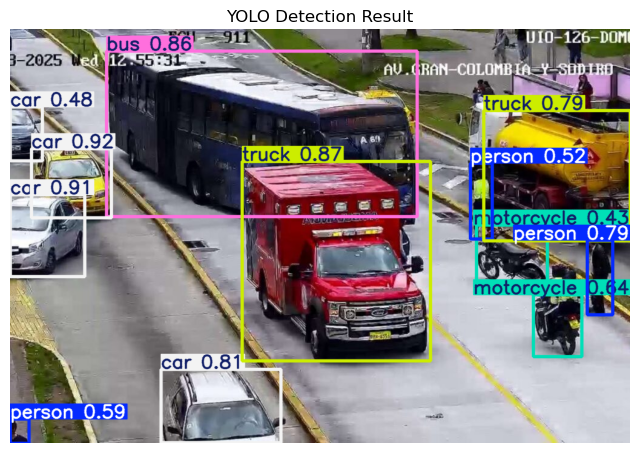

In [2]:
evaluate_image(source1,0.4, input_allowed_classes=list(range(40)))

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

## Limitacion de etiquetas

Se utilizar unicamente las etiquetas antes mencionadas"

- Bus
- Auto
- Motocicleta


Se inicia con las pruebas sobre imagenes para la deteccion de las imagenes deseadas


image 1/1 /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/ImagenTesting2.png: 384x640 1 car, 1 bus, 112.1ms
Speed: 24.1ms preprocess, 112.1ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/runs/detect/yolo_results


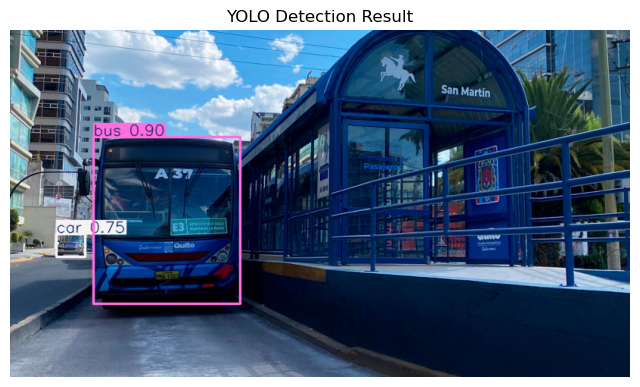


image 1/1 /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/ImagenTesting1.png: 448x640 4 cars, 2 motorcycles, 1 bus, 124.6ms
Speed: 1.5ms preprocess, 124.6ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/runs/detect/yolo_results


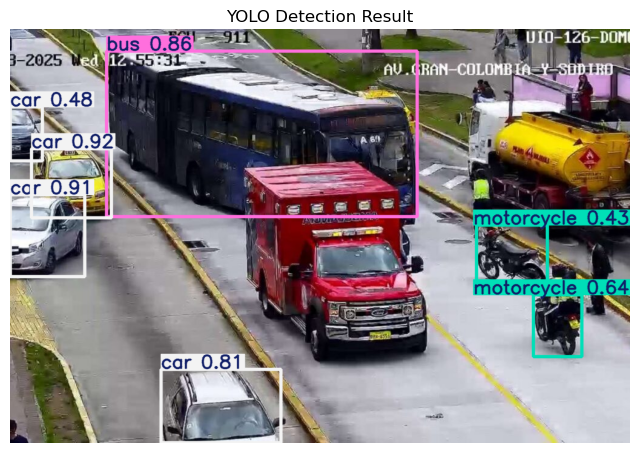


image 1/1 /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/ImagenTesting3.jpeg: 352x640 2 cars, 49.6ms
Speed: 1.2ms preprocess, 49.6ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /Users/ivan/Desktop/Projects/maestria/vision_computer/clase_3/runs/detect/yolo_results


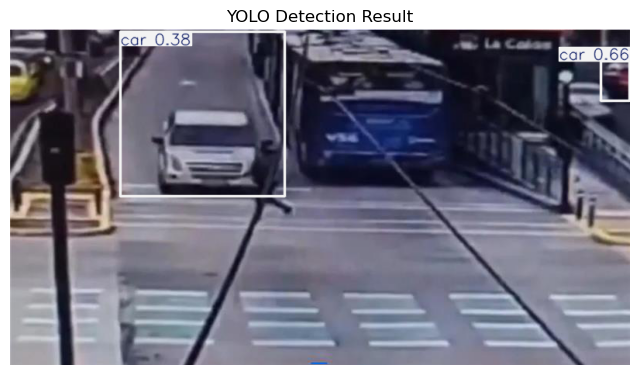

In [3]:
  # Evaluar con umbral de confianza del 40% y clases permitidas (person, car, motorbike, bus)
evaluate_image(source, 0.4)
evaluate_image(source1,0.4)
evaluate_image(source2, 0.3)

## Evaluacion del Modelo en Video

Se evalua el modelos sobre un video para visualizar las detecciones

In [4]:
video_path = "./video_testing.mp4"
# video_path = "./video_testing_1mp4"

# Open video
cap = cv2.VideoCapture(video_path)

# Verify video opened correctly
if not cap.isOpened():
    print("Error: Could not open video. Check the path.")
else:
    print("Video loaded successfully. Press 'q' to exit.")
    
    # Process each video frame
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break  # Finish when video ends
            
        # Run detection with YOLO
        results = model(frame,classes=allowed_classes,conf=0.3)
        
        # Draw bounding boxes
        for result in results:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())
                class_id = int(box.cls[0].cpu().numpy())
                
                # Only show detections with confidence > 50%
                if confidence > 0.5:
                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Show label
                    label = f"{model.names[class_id]}: {confidence:.2f}"
                    cv2.putText(frame, label, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Show frame with detections
        cv2.imshow('Object Detection', frame)
        
        # Exit with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()
print("Processing completed.")

Video loaded successfully. Press 'q' to exit.

0: 640x384 4 cars, 109.7ms
Speed: 29.7ms preprocess, 109.7ms inference, 5.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 131.5ms
Speed: 3.0ms preprocess, 131.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 95.0ms
Speed: 1.4ms preprocess, 95.0ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 106.1ms
Speed: 1.5ms preprocess, 106.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 82.1ms
Speed: 6.4ms preprocess, 82.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 62.9ms
Speed: 2.2ms preprocess, 62.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 cars, 49.6ms
Speed: 2.1ms preprocess, 49.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 5 cars, 1 bus, 103.1ms
Speed: 1.4ms preprocess, 103.1ms inference, 

### Captura video


Se muestra captura de pantalla de la evaluacion del modelo

![Resultado Video](./resultado_video.png)